# HRV Data Analysis Notebook
Interactive exploration of `df_hrv.pkl`

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

df = pd.read_pickle('df_hrv.pkl')
print(f'Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Memory: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')

Loaded: 10,589 rows x 285 columns
Memory: 16.6 MB


## 1. Quick Look at the Data

In [2]:
# First few rows
df.head()

,group,username,task_level,mmse_group,mmse,1,2,3,4,5,...,stanford_pilot|detection|meditation|med_vs_detection|pca_3,stanford_pilot|detection|meditation|med_vs_detection|pca_4,stanford_pilot|detection|meditation|med_vs_detection|ridge_cv,startTime,stimulationEvents,systemEvents,userEvents,year_of_session,yob,error
0,Mind Wave,F_1955_EY_a,beeps_right,healthy,30.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,-1.0,71.0,50.0,1.0,2025.0,1955.0,NaN
1,Mind Wave,F_1955_EY_a,d1,healthy,30.0,71.019867,72.839897,61.755955,62.655033,82.529953,...,44.186363,46.491863,44.810295,-1.0,71.0,50.0,1.0,2025.0,1955.0,0.000000
2,Mind Wave,F_1955_EY_a,d2,healthy,30.0,68.152397,71.534233,61.422611,60.780632,83.632942,...,38.813221,49.763802,43.248302,-1.0,71.0,50.0,1.0,2025.0,1955.0,0.114754
3,Mind Wave,F_1955_EY_a,emotion_happy,healthy,30.0,80.422607,77.666527,68.810417,73.701477,85.938187,...,52.306351,42.184723,54.789825,-1.0,71.0,50.0,1.0,2025.0,1955.0,NaN
4,Mind Wave,F_1955_EY_a,emotion_sad,healthy,30.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,-1.0,71.0,50.0,1.0,2025.0,1955.0,NaN


In [3]:
# All column names grouped by type
print('=== COLUMN TYPES ===')
for dtype in df.dtypes.unique():
    cols = df.columns[df.dtypes == dtype].tolist()
    print(f'\n{dtype} ({len(cols)} columns):')
    print(f'  {cols}')

=== COLUMN TYPES ===

object (6 columns):
  ['group', 'mmse_group', 'F-DOPA date', 'f_dopa_group', 'year_of_session', 'yob']

str (2 columns):
  ['username', 'task_level']

float64 (18 columns):
  ['mmse', 'PNN50', 'RMSSD', 'SDNN', 'accuracy', 'age', 'durationSec', 'event_timestamp', 'index', 'keycode', 'negative_accuracy', 'positive_accuracy', 'session_timestamp', 'startTime', 'stimulationEvents', 'systemEvents', 'userEvents', 'error']

float32 (259 columns):
  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 'A0', 'A1', 'A10', 'A11', 'A12', 'A

In [4]:
# Null percentage per column (sorted, only showing cols with nulls)
null_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
null_pct = null_pct[null_pct > 0]
print(f'{len(null_pct)} columns have nulls:\n')
print(null_pct.round(1).to_string())

275 columns have nulls:

keycode                                                                        100.0
F-DOPA date                                                                     97.2
f_dopa_group                                                                    97.2
PNN50                                                                           90.8
RMSSD                                                                           90.7
SDNN                                                                            90.7
negative_accuracy                                                               59.3
responsetime                                                                    49.7
positive_accuracy                                                               44.8
yob                                                                             44.7
year_of_session                                                                 44.7
accuracy                                

## 2. Categorical / Group Variables

In [5]:
# Study groups
print('=== GROUPS ===')
print(df['group'].value_counts().to_string())
print(f'\n=== MMSE GROUPS ===')
print(df['mmse_group'].value_counts().to_string())
print(f'\n=== TASK LEVELS ===')
print(df['task_level'].value_counts().to_string())

=== GROUPS ===
group
Forest treatment           2459
Music Lab Indre            1200
Mind Wave                  1098
Ariel testing               890
Dorot - third trial         836
Masa 2025                   688
Dorot - follow up           668
Haifa University            588
Sourasky Medical Center     310
Masa Daniel                 257
Masa Anna                   251
Masa Elena                  246
Masa Donna                  246
Doctors Studio              222
Olympic gymnasts Russia     156
Lior Haramaty Group         136
Dorot                       126
Huemn Houston               118
Mehrdad TBI                  87
Nahariya simulator            7

=== MMSE GROUPS ===
mmse_group
0          7551
healthy    2135
MCI         682
MD          221

=== TASK LEVELS ===
task_level
d2                            883
d1                            845
rest_closed                   758
nb1                           756
nb2                           667
rest_open                     477
nb0    

In [6]:
# How many subjects per group?
print('Unique subjects per group:')
print(df.groupby('group')['username'].nunique().sort_values(ascending=False).to_string())

Unique subjects per group:
group
Mind Wave                  188
Forest treatment           147
Music Lab Indre             93
Dorot - follow up           80
Dorot - third trial         77
Ariel testing               76
Dorot                       48
Haifa University            47
Masa 2025                   41
Masa Anna                   32
Sourasky Medical Center     31
Olympic gymnasts Russia     26
Doctors Studio              18
Masa Elena                  18
Masa Donna                  17
Lior Haramaty Group         13
Huemn Houston               10
Masa Daniel                  8
Mehrdad TBI                  6
Nahariya simulator           1


## 3. Key Numeric Variables

In [7]:
# HRV features
hrv_cols = ['PNN50', 'RMSSD', 'SDNN']
print('=== HRV Features ===')
print(df[hrv_cols].describe().round(2).to_string())
print(f'\nRows with HRV data: {df[hrv_cols].dropna(how="all").shape[0]:,} / {len(df):,}')

=== HRV Features ===
        PNN50   RMSSD    SDNN
count  979.00  980.00  980.00
mean    22.71   46.33   57.53
std     14.07   16.38   20.44
min      0.00    4.17    4.14
25%     11.02   33.77   42.58
50%     22.42   46.04   55.16
75%     31.51   55.62   68.55
max     90.91  110.29  149.96

Rows with HRV data: 980 / 10,589


In [8]:
# EEG band powers
eeg_bands = ['Alpha', 'Beta', 'Delta', 'Gamma', 'Theta']
print('=== EEG Band Powers ===')
print(df[eeg_bands].describe().round(2).to_string())

=== EEG Band Powers ===
          Alpha      Beta     Delta     Gamma     Theta
count  10575.00  10575.00  10575.00  10575.00  10575.00
mean     -11.07    -11.80      6.10    -12.88     -4.82
std        4.50      5.35      5.87      5.87      5.31
min      -42.25    -42.27    -38.57    -42.62    -41.41
25%      -13.49    -15.37      2.34    -16.81     -8.09
50%      -11.53    -12.27      5.84    -13.14     -5.27
75%       -9.46     -8.90      9.30     -9.43     -2.25
max       40.17     36.22     50.71     34.50     46.19


In [9]:
# Behavioral / performance metrics
perf_cols = ['accuracy', 'error', 'positive_accuracy', 'negative_accuracy', 'responsetime']
print('=== Performance Metrics ===')
print(df[perf_cols].describe().round(3).to_string())

=== Performance Metrics ===
       accuracy     error  positive_accuracy  negative_accuracy  responsetime
count  6034.000  6034.000           5845.000           4314.000      5331.000
mean      0.828     0.172              0.757              0.873      1728.370
std       0.214     0.214              0.336              0.213      1046.715
min       0.000     0.000              0.000              0.000        18.000
25%       0.714     0.000              0.600              0.800      1234.292
50%       0.917     0.083              1.000              1.000      1499.000
75%       1.000     0.286              1.000              1.000      1932.967
max       1.000     1.000              1.000              1.000     23589.000


## 4. Clean Mind Wave Usernames
Standardize usernames in the Mind Wave group to format `F/M_YYYY_XX` (gender_yearborn_initials).  
Merges duplicate entries caused by `_a`/`_b` session suffixes, typos, extra underscores, case differences, etc.

In [10]:
# --- Mind Wave username cleaning ---
mw_mask = df['group'] == 'Mind Wave'
print(f'Mind Wave BEFORE cleaning: {df.loc[mw_mask, "username"].nunique()} unique usernames, {mw_mask.sum()} rows')

# Drop test row
test_mask = mw_mask & (df['username'] == 'test 1_b')
df = df[~test_mask].copy()
mw_mask = df['group'] == 'Mind Wave'

# Full explicit mapping: old username -> new standardized username
mw_rename = {
    # F_1955_EY - two variants with different underscores
    'F_1955_EY_a':       'F_1955_EY',
    'F_1955__EY_a':      'F_1955_EY',
    # F_1955_HM
    'F_1955__HM_a':      'F_1955_HM',
    'F_1955__HM_b':      'F_1955_HM',
    # F_1957_HE
    'F_1957__HE_a':      'F_1957_HE',
    'F_1957__HE_b':      'F_1957_HE',
    # F_1957_NA
    'F_1957__NA_a':      'F_1957_NA',
    'F_1957__NA_b':      'F_1957_NA',
    # F_1958_AF - single vs double underscore
    'F_1958_AF_a':       'F_1958_AF',
    'F_1958_AF_b':       'F_1958_AF',
    'F_1958__AF_a':      'F_1958_AF',
    'F_1958__AF_b':      'F_1958_AF',
    # F_1960_AO
    'F_1960__AO_a':      'F_1960_AO',
    'F_1960__AO_b':      'F_1960_AO',
    # F_1960_NB (was NBN - using first 2 initials)
    'F_1960__NBN_b':     'F_1960_NB',
    'F_1960__NBN_c':     'F_1960_NB',
    'F_1960__NBN_d':     'F_1960_NB',
    'F_1960__NBN_e':     'F_1960_NB',
    'F_1960__NBN_f':     'F_1960_NB',
    # F_1961_YD
    'F_1961__YD_a':      'F_1961_YD',
    'F_1961__YD_b':      'F_1961_YD',
    # F_1962_RS - single vs double underscore
    'F_1962_RS_a':       'F_1962_RS',
    'F_1962__RS_a':      'F_1962_RS',
    'F_1962__RS_b':      'F_1962_RS',
    # F_1963_ES
    'F_1963__ES_a':      'F_1963_ES',
    'F_1963__ES_c':      'F_1963_ES',
    # F_1963_OM - case difference (Om vs OM)
    'F_1963__OM_a':      'F_1963_OM',
    'F_1963__Om_a':      'F_1963_OM',
    # F_1963_RS
    'F_1963__RS_a':      'F_1963_RS',
    'F_1963__RS_b':      'F_1963_RS',
    # F_1966_IK
    'F_1966__IK_a':      'F_1966_IK',
    'F_1966__IK_b':      'F_1966_IK',
    # F_1967_GL - includes extra underscore variant F__1967
    'F_1967__GL_a':      'F_1967_GL',
    'F_1967__GL_b':      'F_1967_GL',
    'F_1967__GL_e':      'F_1967_GL',
    'F__1967__GL_a':     'F_1967_GL',
    # F_1967_RS - single vs double underscore
    'F_1967_RS_a':       'F_1967_RS',
    'F_1967__RS_a':      'F_1967_RS',
    # F_1968_GR
    'F_1968__GR_a':      'F_1968_GR',
    'F_1968__GR_b':      'F_1968_GR',
    'F_1968__GR_c':      'F_1968_GR',
    'F_1968__GR_d':      'F_1968_GR',
    # F_1969_DW - single vs double underscore
    'F_1969_DW_a':       'F_1969_DW',
    'F_1969__DW_b':      'F_1969_DW',
    # F_1969_MS
    'F_1969__MS_a':      'F_1969_MS',
    'F_1969__MS_b':      'F_1969_MS',
    # F_1970_LA
    'F_1970__LA_a':      'F_1970_LA',
    'F_1970__LA_b':      'F_1970_LA',
    # F_1972_HP (was HPM - using first 2 initials)
    'F_1972__HPM_a':     'F_1972_HP',
    'F_1972__HPM_b':     'F_1972_HP',
    'F_1972__HPM_c':     'F_1972_HP',
    'F_1972__HPM_d':     'F_1972_HP',
    # F_1972_OR
    'F_1972__OR_a':      'F_1972_OR',
    'F_1972__OR_b':      'F_1972_OR',
    # F_1972_SN
    'F_1972__SN_a':      'F_1972_SN',
    'F_1972__SN_b':      'F_1972_SN',
    'F_1972__SN_c':      'F_1972_SN',
    'F_1972__SN_d':      'F_1972_SN',
    # F_1974_SL
    'F_1974__SL_a':      'F_1974_SL',
    'F_1974__SL_b':      'F_1974_SL',
    # F_1975_ST - single vs double underscore
    'F_1975_ST_a':       'F_1975_ST',
    'F_1975__ST_h':      'F_1975_ST',
    'F_1975__ST_i':      'F_1975_ST',
    'F_1975__ST_j':      'F_1975_ST',
    # F_1975_LD
    'F_1975__LD_a':      'F_1975_LD',
    'F_1975__LD_b':      'F_1975_LD',
    # F_1976_MJ - includes MJT variant (same person)
    'F_1976__MJT_a':     'F_1976_MJ',
    'F_1976__MJT_b':     'F_1976_MJ',
    'F_1976__MJ_a':      'F_1976_MJ',
    'F_1976__MJ_b':      'F_1976_MJ',
    'F_1976__MJ_c':      'F_1976_MJ',
    'F_1976__MJ_d':      'F_1976_MJ',
    # F_1976_RZ
    'F_1976__RZ_a':      'F_1976_RZ',
    'F_1976__RZ_b':      'F_1976_RZ',
    # F_1981_HC
    'F_1981__HC_a':      'F_1981_HC',
    'F_1981__HC_b':      'F_1981_HC',
    # F_1982_IS - single vs double underscore
    'F_1982_IS_a':       'F_1982_IS',
    'F_1982__IS_a':      'F_1982_IS',
    'F_1982__IS_b':      'F_1982_IS',
    'F_1982__IS_c':      'F_1982_IS',
    # F_1982_LD
    'F_1982__LD_a':      'F_1982_LD',
    'F_1982__LD_b':      'F_1982_LD',
    # F_1985_MS - includes garbled unicode variant
    'F_1985__MS_a':      'F_1985_MS',
    'F_1985\u05b9\u05b9\u05b9\u05b9--MS_a': 'F_1985_MS',
    # F_1987_KB - missing underscore variant
    'F_1987KB_a':        'F_1987_KB',
    'F_1987__KB_a':      'F_1987_KB',
    # F_1988_NY
    'F_1988__NY_a':      'F_1988_NY',
    'F_1988__NY_b':      'F_1988_NY',
    # F_1991_AS - single vs double underscore
    'F_1991_AS_a':       'F_1991_AS',
    'F_1991__AS_a':      'F_1991_AS',
    # M_1994_DH - was incorrectly labeled F in one session
    'F_1994__DH_a':      'M_1994_DH',
    'M_1994__DH_a':      'M_1994_DH',
    # F_1997_RA
    'F_1997__RA_a':      'F_1997_RA',
    'F_1997__RA_b':      'F_1997_RA',
    # F_1999_MR - single vs double underscore
    'F_1999_MR_a':       'F_1999_MR',
    'F_1999__MR_a':      'F_1999_MR',
    # F_2000_SS - single vs double underscore
    'F_2000_SS_a':       'F_2000_SS',
    'F_2000__SS_a':      'F_2000_SS',
    'F_2000__SS_b':      'F_2000_SS',
    # F_2001_OR
    'F_2001__OR_a':      'F_2001_OR',
    'F_2001__OR_b':      'F_2001_OR',
    # F_2002_MK - includes space typo variant
    'F_2002__ MK_a':     'F_2002_MK',
    'F_2002__MK_a':      'F_2002_MK',
    'F_2002__MK_b':      'F_2002_MK',
    'F_2002__MK_c':      'F_2002_MK',
    # F_2003_OB - single vs double underscore
    'F_2003_OB_a':       'F_2003_OB',
    'F_2003__OB_a':      'F_2003_OB',
    'F_2003__OB_b':      'F_2003_OB',
    'F_2003__OB_c':      'F_2003_OB',
    # --- Males ---
    # M_1948_MH
    'M_1948__MH_b':      'M_1948_MH',
    'M_1948__MH_d':      'M_1948_MH',
    # M_1948_NR
    'M_1948__NR_a':      'M_1948_NR',
    'M_1948__NR_b':      'M_1948_NR',
    'M_1948__NR_c':      'M_1948_NR',
    'M_1948__NR_d':      'M_1948_NR',
    # M_1951_SA
    'M_1951__SA_a':      'M_1951_SA',
    'M_1951__SA_b':      'M_1951_SA',
    # M_1952_MO
    'M_1952__MO_a':      'M_1952_MO',
    'M_1952__MO_b':      'M_1952_MO',
    # M_1953_EY - includes shorthand ey1953
    'M_1953__EY_a':      'M_1953_EY',
    'M_1953__EY_b':      'M_1953_EY',
    'M_1953__EY_d':      'M_1953_EY',
    'M_1953__EY_e':      'M_1953_EY',
    'ey1953_a':          'M_1953_EY',
    # M_1954_AA
    'M_1954__AA_a':      'M_1954_AA',
    'M_1954__AA_b':      'M_1954_AA',
    # M_1954_DK
    'M_1954__DK_b':      'M_1954_DK',
    'M_1954__DK_c':      'M_1954_DK',
    # M_1956_SE - single vs double underscore
    'M_1956_SE_a':       'M_1956_SE',
    'M_1956__SE_a':      'M_1956_SE',
    # M_1956_BS
    'M_1956__BS_a':      'M_1956_BS',
    'M_1956__BS_b':      'M_1956_BS',
    # M_1957_GL
    'M_1957__GL_a':      'M_1957_GL',
    'M_1957__GL_b':      'M_1957_GL',
    'M_1957__GL_c':      'M_1957_GL',
    'M_1957__GL_d':      'M_1957_GL',
    'M_1957__GL_e':      'M_1957_GL',
    'M_1957__GL_f':      'M_1957_GL',
    # M_1957_IS
    'M_1957__IS_a':      'M_1957_IS',
    'M_1957__IS_c':      'M_1957_IS',
    # M_1962_EB
    'M_1962__EB_a':      'M_1962_EB',
    'M_1962__EB_b':      'M_1962_EB',
    'M_1962__EB_c':      'M_1962_EB',
    'M_1962__EB_d':      'M_1962_EB',
    # M_1963_MZ - single vs double underscore
    'M_1963_MZ_a':       'M_1963_MZ',
    'M_1963__MZ_a':      'M_1963_MZ',
    'M_1963__MZ_b':      'M_1963_MZ',
    'M_1963__MZ_c':      'M_1963_MZ',
    # M_1964_OD
    'M_1964__OD_a':      'M_1964_OD',
    'M_1964__OD_c':      'M_1964_OD',
    # M_1965_YO - single vs double underscore
    'M_1965_YO_a':       'M_1965_YO',
    'M_1965__YO_a':      'M_1965_YO',
    # M_1967_ES
    'M_1967__ES_a':      'M_1967_ES',
    'M_1967__ES_b':      'M_1967_ES',
    # M_1969_IK
    'M_1969__IK_a':      'M_1969_IK',
    'M_1969__IK_b':      'M_1969_IK',
    # M_1970_AH - includes garbled unicode variant
    'M_1970__AH_a':      'M_1970_AH',
    'M_1970__AH_b':      'M_1970_AH',
    'M_1970__AH_c':      'M_1970_AH',
    'M_1970__AH_d':      'M_1970_AH',
    'M_1970__AH_e':      'M_1970_AH',
    'M_1970__AH_f':      'M_1970_AH',
    'M_1970__AH_h':      'M_1970_AH',
    'M_1970__AH_i':      'M_1970_AH',
    'M\u05b9\u05b9-1970--AH_a': 'M_1970_AH',
    # M_1971_GR
    'M_1971__GR_a':      'M_1971_GR',
    'M_1971__GR_b':      'M_1971_GR',
    # M_1971_GS - shorthand gs1971 (different person from GR)
    'gs1971_a':          'M_1971_GS',
    'gs1971_b':          'M_1971_GS',
    # M_1977_RS
    'M_1977__RS_a':      'M_1977_RS',
    'M_1977__RS_b':      'M_1977_RS',
    # M_1985_AL
    'M_1985__AL_a':      'M_1985_AL',
    'M_1985__AL_b':      'M_1985_AL',
    # M_1986_AS - includes ASH variant (same person)
    'M_1986__ASH_a':     'M_1986_AS',
    'M_1986__ASH_b':     'M_1986_AS',
    'M_1986__AS_a':      'M_1986_AS',
    'M_1986__AS_b':      'M_1986_AS',
    # M_1987_MO
    'M_1987__MO_a':      'M_1987_MO',
    'M_1987__MO_b':      'M_1987_MO',
    # M_1988_NB
    'M_1988__NB_a':      'M_1988_NB',
    'M_1988__NB_b':      'M_1988_NB',
    'M_1988__NB_c':      'M_1988_NB',
    'M_1988__NB_d':      'M_1988_NB',
    # M_1995_ST
    'M_1995__ST_a':      'M_1995_ST',
    'M_1995__ST_b':      'M_1995_ST',
    # M_2000_YH - shorthand YH2000
    'YH 2000_a':         'M_2000_YH',
    'YH2000_a':          'M_2000_YH',
}

# Apply the mapping (only for Mind Wave group)
df.loc[mw_mask, 'username'] = df.loc[mw_mask, 'username'].map(
    lambda x: mw_rename.get(x, x)
)

# Verify
mw_mask = df['group'] == 'Mind Wave'
print(f'Mind Wave AFTER cleaning:  {df.loc[mw_mask, "username"].nunique()} unique usernames, {mw_mask.sum()} rows')
print(f'\nCleaned usernames:')
for u in sorted(df.loc[mw_mask, 'username'].unique()):
    count = (df.loc[mw_mask, 'username'] == u).sum()
    print(f'  {u:20s}  ({count} rows)')

Mind Wave BEFORE cleaning: 188 unique usernames, 1098 rows
Mind Wave AFTER cleaning:  68 unique usernames, 1097 rows

Cleaned usernames:
  F_1955_EY             (12 rows)
  F_1955_HM             (12 rows)
  F_1957_HE             (12 rows)
  F_1957_NA             (12 rows)
  F_1958_AF             (24 rows)
  F_1960_AO             (12 rows)
  F_1960_NB             (25 rows)
  F_1961_YD             (12 rows)
  F_1962_RS             (19 rows)
  F_1963_ES             (12 rows)
  F_1963_OM             (12 rows)
  F_1963_RS             (12 rows)
  F_1966_IK             (7 rows)
  F_1967_GL             (24 rows)
  F_1967_RS             (10 rows)
  F_1968_GR             (24 rows)
  F_1969_DW             (12 rows)
  F_1969_MS             (12 rows)
  F_1970_LA             (12 rows)
  F_1972_HP             (24 rows)
  F_1972_OR             (12 rows)
  F_1972_SN             (24 rows)
  F_1974_SL             (12 rows)
  F_1975_LD             (12 rows)
  F_1975_ST             (24 rows)
  F_1976_MJ   

## 5. Add Cortisol & LNRMSSD from CSV (Forest Treatment)
Merge `first_session_all.csv` data into the dataframe.  
The CSV has LNRMSSD and CORTISOL measured at two time points (TIME=1, TIME=2).  
We match Forest treatment usernames (which contain a numeric ID) to the CSV's `username` column.

In [11]:
import re

# --- Load CSV and pivot to get TIME 1 and TIME 2 as separate columns ---
csv_raw = pd.read_csv("first_session_all.csv")
csv_t1 = csv_raw[csv_raw["TIME"] == 1][["username", "LNRMSSD", "CORTIZOL"]].rename(
    columns={"LNRMSSD": "LNRMSSD_1", "CORTIZOL": "CORTISOL_1"})
csv_t2 = csv_raw[csv_raw["TIME"] == 2][["username", "LNRMSSD", "CORTIZOL"]].rename(
    columns={"LNRMSSD": "LNRMSSD_2", "CORTIZOL": "CORTISOL_2"})
csv_pivot = csv_t1.merge(csv_t2, on="username", how="outer")

# --- Extract numeric ID from Forest treatment usernames ---
# Collision resolution: when two df users share the same numeric ID,
# we use CSV age to pick the correct one.
# id 47: CSV age=56 -> yob 1969; id 67: CSV age=41 -> yob 1983; id 428: CSV age=48 -> yob 1977
collision_correct_yob = {47: 1969, 67: 1983, 428: 1977}

def extract_csv_id(username):
    parts = re.split(r"[_]+", username.upper().strip())
    nums = [p for p in parts if p.isdigit()]
    if len(nums) < 2:
        return None, None
    year_candidates = [n for n in nums if len(n) == 4 and (n.startswith("19") or n.startswith("20"))]
    id_candidates = [n for n in nums if n not in year_candidates]
    if not id_candidates:
        id_candidates = [n for n in nums if not (n.startswith("19") or n.startswith("20")) or len(n) < 4]
        if not id_candidates:
            id_candidates = [nums[1]]
    return int(id_candidates[0]), int(year_candidates[0]) if year_candidates else None

ft_mask = df["group"] == "Forest treatment"
username_to_csvid = {}
for u in df.loc[ft_mask, "username"].unique():
    csv_id, yob = extract_csv_id(u)
    if csv_id is None:
        continue
    if csv_id in collision_correct_yob and yob != collision_correct_yob[csv_id]:
        continue  # skip the wrong person for this colliding ID
    username_to_csvid[u] = csv_id

# --- Merge into df ---
df["_csv_id"] = df["username"].map(username_to_csvid)
df = df.merge(csv_pivot, left_on="_csv_id", right_on="username", how="left", suffixes=("", "_csv"))
df.drop(columns=["_csv_id", "username_csv"], inplace=True, errors="ignore")

# --- Verify ---
ft_mask = df["group"] == "Forest treatment"
print(f"Forest treatment rows with LNRMSSD_1: {(ft_mask & df['LNRMSSD_1'].notna()).sum()}")
print(f"Forest treatment rows with CORTISOL_1: {(ft_mask & df['CORTISOL_1'].notna()).sum()}")
print(f"Non-Forest rows with data:  {(~ft_mask & df['LNRMSSD_1'].notna()).sum()} (should be 0)")
print()
print("Sample:")
sample = df.loc[ft_mask & df["LNRMSSD_1"].notna(),
    ["username", "LNRMSSD_1", "LNRMSSD_2", "CORTISOL_1", "CORTISOL_2"]
].drop_duplicates("username").head(10)
print(sample.to_string(index=False))
print(f"df shape: {df.shape}")

Forest treatment rows with LNRMSSD_1: 962
Forest treatment rows with CORTISOL_1: 564
Non-Forest rows with data:  0 (should be 0)

Sample:
   username  LNRMSSD_1  LNRMSSD_2  CORTISOL_1  CORTISOL_2
F_1950__253       3.66       3.60         NaN         NaN
F_1951__318       3.62       3.62      1433.0         NaN
F_1953__286       3.75       3.38       417.5         NaN
F_1956__177       3.58       3.35      2691.0         NaN
F_1957__271       3.65       3.62         NaN       506.1
F_1958__129       3.52       3.52      1399.0        50.1
 F_1959_041       3.70       3.75         NaN         NaN
F_1959__313       3.74       3.54       835.0         NaN
 F_1959__41       3.70       3.75         NaN         NaN
F_1959__419       3.46       3.43         NaN         NaN
df shape: (10588, 289)


## 6. Brain State Classification Model
Predict cognitive state (rest / mental_load / high_mental_load) from Neurosteer biomarkers.

In [12]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

# --- Define conditions (matching metric_info.md) ---
condition_map = {
    'rest_closed': 'rest', 'rest_open': 'rest', 'rest_music': 'rest',
    'rest_positive': 'rest', 'rest_clear': 'rest', 'rest_wonder': 'rest',
    'd1': 'mental_load', 'd2': 'mental_load', 'nb1': 'mental_load',
    'nb2': 'high_mental_load',
}

# --- Filter and label ---
model_df = df[df['task_level'].isin(condition_map.keys())].copy()
model_df['condition'] = model_df['task_level'].map(condition_map)

# --- Features ---
core_features = ['A0', 'VC9', 'ST4', 'T2', 'Alpha', 'Beta', 'Gamma', 'Delta', 'Theta']

# Derived features (from metric_info.md)
model_df['TBR'] = model_df['Theta'] - model_df['Beta']
model_df['BetaAlpha'] = model_df['Alpha'] - model_df['Beta']

all_features = core_features + ['TBR', 'BetaAlpha']

# --- Drop rows with NaN in features ---
model_df = model_df.dropna(subset=all_features).reset_index(drop=True)

print(f"Dataset: {len(model_df):,} rows, {model_df['username'].nunique()} users")
print(f"\nClass distribution:")
print(model_df['condition'].value_counts().to_string())
print(f"\nFeatures: {all_features}")

Dataset: 5,234 rows, 855 users

Class distribution:
condition
mental_load         2483
rest                2084
high_mental_load     667

Features: ['A0', 'VC9', 'ST4', 'T2', 'Alpha', 'Beta', 'Gamma', 'Delta', 'Theta', 'TBR', 'BetaAlpha']


In [13]:
# --- Train/Test with GroupKFold (no user leakage) ---
X = model_df[all_features].values
y = model_df['condition'].values
groups = model_df['username'].values

le = LabelEncoder()
y_encoded = le.fit_transform(y)

# GroupKFold cross-validation (5 folds)
gkf = GroupKFold(n_splits=5)

# Random Forest
rf = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
y_pred_rf = cross_val_predict(rf, X, y_encoded, groups=groups, cv=gkf)

print("=" * 60)
print("RANDOM FOREST (GroupKFold, 5 folds)")
print("=" * 60)
print(f"Accuracy: {accuracy_score(y_encoded, y_pred_rf):.3f}")
print()
print(classification_report(y_encoded, y_pred_rf, target_names=le.classes_))

# Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42)
y_pred_gb = cross_val_predict(gb, X, y_encoded, groups=groups, cv=gkf)

print("=" * 60)
print("GRADIENT BOOSTING (GroupKFold, 5 folds)")
print("=" * 60)
print(f"Accuracy: {accuracy_score(y_encoded, y_pred_gb):.3f}")
print()
print(classification_report(y_encoded, y_pred_gb, target_names=le.classes_))

RANDOM FOREST (GroupKFold, 5 folds)
Accuracy: 0.544

                  precision    recall  f1-score   support

high_mental_load       0.16      0.01      0.01       667
     mental_load       0.54      0.74      0.63      2483
            rest       0.55      0.49      0.52      2084

        accuracy                           0.54      5234
       macro avg       0.42      0.41      0.38      5234
    weighted avg       0.50      0.54      0.50      5234

GRADIENT BOOSTING (GroupKFold, 5 folds)
Accuracy: 0.526

                  precision    recall  f1-score   support

high_mental_load       0.23      0.04      0.07       667
     mental_load       0.54      0.68      0.60      2483
            rest       0.53      0.50      0.51      2084

        accuracy                           0.53      5234
       macro avg       0.43      0.41      0.39      5234
    weighted avg       0.49      0.53      0.50      5234



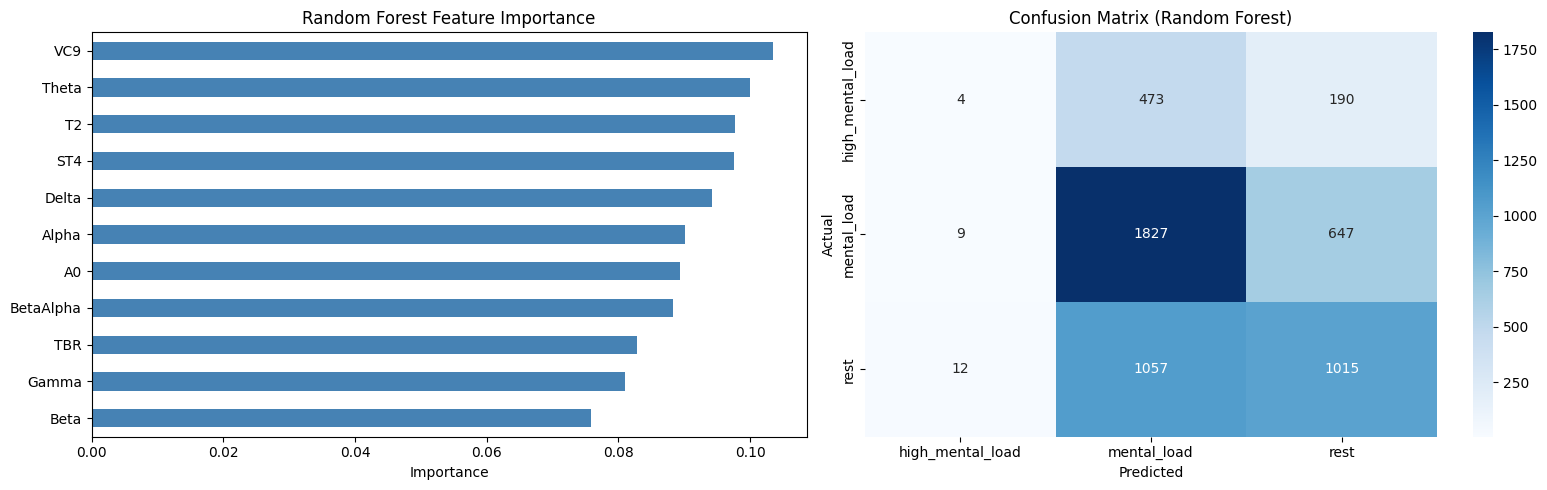


Key findings:
- Top 3 features: VC9, Theta, T2
- Best model accuracy: 0.544


In [14]:
# --- Fit final RF on all data for feature importance ---
rf_final = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf_final.fit(X, y_encoded)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Feature importance
importances = rf_final.feature_importances_
feat_imp = pd.Series(importances, index=all_features).sort_values(ascending=True)
feat_imp.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Random Forest Feature Importance')
axes[0].set_xlabel('Importance')

# Confusion matrix (RF cross-val predictions)
cm = confusion_matrix(y_encoded, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=le.classes_, yticklabels=le.classes_)
axes[1].set_title('Confusion Matrix (Random Forest)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

print("\nKey findings:")
print(f"- Top 3 features: {', '.join(feat_imp.index[-3:][::-1])}")
print(f"- Best model accuracy: {max(accuracy_score(y_encoded, y_pred_rf), accuracy_score(y_encoded, y_pred_gb)):.3f}")

## 7. Per-User Model: Predict Cognitive Decline (mmse_group)
Aggregate biomarkers per user per condition, then predict mmse_group (healthy / MCI / MD).

Users with mmse data and complete features: 142

mmse_group distribution:
mmse_group
healthy    98
MCI        28
MD         16

Accuracy: 0.704

              precision    recall  f1-score   support

         MCI       0.30      0.11      0.16        28
          MD       0.46      0.38      0.41        16
     healthy       0.76      0.93      0.84        98

    accuracy                           0.70       142
   macro avg       0.51      0.47      0.47       142
weighted avg       0.64      0.70      0.66       142



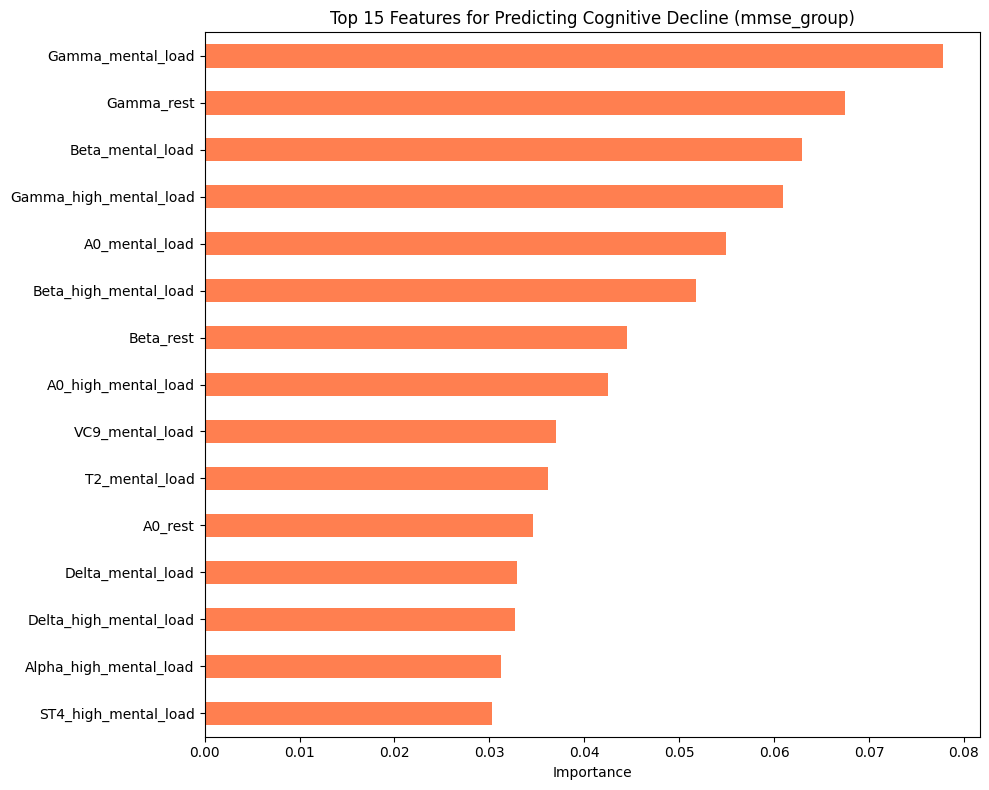

In [15]:
# --- Build user-level features: mean biomarker per condition ---
user_features = []
for user in model_df['username'].unique():
    u_data = model_df[model_df['username'] == user]
    row = {'username': user}

    # mmse_group label
    mmse_val = u_data['mmse_group'].dropna().values
    if len(mmse_val) == 0 or str(mmse_val[0]) == '0':
        continue  # skip users without mmse assessment
    row['mmse_group'] = mmse_val[0]

    # Aggregate features per condition
    for cond in ['rest', 'mental_load', 'high_mental_load']:
        cond_data = u_data[u_data['condition'] == cond]
        for feat in core_features:
            row[f'{feat}_{cond}'] = cond_data[feat].mean() if len(cond_data) > 0 else np.nan

    user_features.append(row)

user_df = pd.DataFrame(user_features)
user_df = user_df.dropna()

print(f"Users with mmse data and complete features: {len(user_df)}")
print(f"\nmmse_group distribution:")
print(user_df['mmse_group'].value_counts().to_string())

if len(user_df) >= 20:
    # Features = all biomarker x condition combinations
    user_feat_cols = [c for c in user_df.columns if c not in ['username', 'mmse_group']]
    X_user = user_df[user_feat_cols].values
    y_user = user_df['mmse_group'].values

    le_mmse = LabelEncoder()
    y_user_enc = le_mmse.fit_transform(y_user)

    # Stratified cross-validation
    from sklearn.model_selection import StratifiedKFold
    n_splits = min(5, min(pd.Series(y_user).value_counts()))
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    rf_user = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
    y_pred_user = cross_val_predict(rf_user, X_user, y_user_enc, cv=skf)

    print(f"\nAccuracy: {accuracy_score(y_user_enc, y_pred_user):.3f}")
    print()
    print(classification_report(y_user_enc, y_pred_user, target_names=le_mmse.classes_))

    # Feature importance
    rf_user.fit(X_user, y_user_enc)
    feat_imp_user = pd.Series(rf_user.feature_importances_, index=user_feat_cols).sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(10, 8))
    feat_imp_user.tail(15).plot(kind='barh', ax=ax, color='coral')
    ax.set_title('Top 15 Features for Predicting Cognitive Decline (mmse_group)')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()
else:
    print("Not enough users with mmse data for modeling.")

## 8. Metric Refinement Analysis
Validate each of the 14 individual report metrics against external measures (MMSE, age, HRV, F-DOPA, mmse_group).
Analyze task groupings and establish normative reference ranges.

In [16]:
# ====================================================================
# Compute all 14 report metrics per user + external measures
# ====================================================================
from scipy import stats

# Derived features
df['TBR'] = df['Theta'] - df['Beta']
df['BetaAlpha'] = df['Alpha'] - df['Beta']

# Task groupings from metric_info.md
rest_tasks_report = ['rest_closed', 'rest_music', 'rest_clear', 'rest_open']
mid_load_tasks = ['d2', 'nb0', 'nb1']
high_load_tasks = ['nb2', 'nb3', 'clock', 'late_recall']
attention_tasks = ['d1', 'd2', 'nb2', 'nb3', 'clock', 'late_recall']
stress_load_tasks = ['d2', 'nb2', 'nb3', 'clock', 'late_recall']
rt_mid_tasks = ['d1', 'nb0']
rt_high_tasks = ['d2', 'nb2', 'nb3', 'clock', 'late_recall', 'nb1']
err_low_tasks = ['d1', 'nb0']
err_high_tasks = ['d2', 'nb1', 'nb2', 'nb3', 'clock', 'immediate_recall', 'late_recall']

def user_metric(user_df, feature, tasks, flip=False, max_clip=None, invert_to_error=False):
    subset = user_df[user_df['task_level'].isin(tasks)]
    if subset.empty or feature not in subset.columns:
        return np.nan
    avg = subset[feature].mean()
    if pd.isna(avg): return np.nan
    if max_clip and avg > max_clip: avg = max_clip
    if flip: avg = 100 - avg
    if invert_to_error: avg = (1 - avg) * 100
    return avg

records = []
for u in df['username'].unique():
    udf = df[df['username'] == u]
    def first_val(col):
        v = udf[col].dropna().values
        return v[0] if len(v) > 0 else np.nan
    rec = {
        'username': u,
        'mmse': first_val('mmse'),
        'mmse_group': first_val('mmse_group'),
        'age': first_val('age'),
        'f_dopa_group': first_val('f_dopa_group'),
        'group': udf['group'].values[0],
        # HRV (mean across tasks)
        'PNN50': udf['PNN50'].dropna().mean() if udf['PNN50'].notna().any() else np.nan,
        'RMSSD': udf['RMSSD'].dropna().mean() if udf['RMSSD'].notna().any() else np.nan,
        'SDNN': udf['SDNN'].dropna().mean() if udf['SDNN'].notna().any() else np.nan,
    }
    # Cortisol & LNRMSSD (from CSV merge)
    for col in ['CORTISOL_1', 'CORTISOL_2', 'LNRMSSD_1', 'LNRMSSD_2']:
        rec[col] = first_val(col) if col in udf.columns else np.nan
    # Cortisol & LNRMSSD change
    c1, c2 = rec.get('CORTISOL_1', np.nan), rec.get('CORTISOL_2', np.nan)
    rec['CORTISOL_change'] = c2 - c1 if pd.notna(c1) and pd.notna(c2) else np.nan
    l1, l2 = rec.get('LNRMSSD_1', np.nan), rec.get('LNRMSSD_2', np.nan)
    rec['LNRMSSD_change'] = l2 - l1 if pd.notna(l1) and pd.notna(l2) else np.nan
    # --- The 14 report metrics ---
    rec['M01_A0_rest'] = user_metric(udf, 'A0', rest_tasks_report, max_clip=100)
    rec['M02_A0_mid'] = user_metric(udf, 'A0', mid_load_tasks, max_clip=100)
    rec['M03_A0_high'] = user_metric(udf, 'A0', high_load_tasks, max_clip=100)
    rec['M05_VC9_rest'] = user_metric(udf, 'VC9', rest_tasks_report, max_clip=100)
    rec['M06_VC9_high'] = user_metric(udf, 'VC9', high_load_tasks, max_clip=100)
    rec['M08_TBR_attention'] = user_metric(udf, 'TBR', attention_tasks)
    rec['M09_ST4_stress_rest'] = user_metric(udf, 'ST4', rest_tasks_report, max_clip=100)
    rec['M10_T2_stress_load'] = user_metric(udf, 'T2', stress_load_tasks, max_clip=100, flip=True)
    rec['M11_BetaAlpha_stress'] = user_metric(udf, 'BetaAlpha', stress_load_tasks)
    rec['M12_RT_mid'] = user_metric(udf, 'responsetime', rt_mid_tasks)
    rec['M13_RT_high'] = user_metric(udf, 'responsetime', rt_high_tasks)
    rec['M14_Error_low'] = user_metric(udf, 'accuracy', err_low_tasks, invert_to_error=True)
    rec['M15_Error_high'] = user_metric(udf, 'accuracy', err_high_tasks, invert_to_error=True)
    # M04: A0 average
    a0s = [rec['M01_A0_rest'], rec['M02_A0_mid'], rec['M03_A0_high']]
    rec['M04_A0_avg'] = np.mean(a0s) if all(not np.isnan(v) for v in a0s) else np.nan
    # M07: VC9 difference
    v_r, v_h = rec['M05_VC9_rest'], rec['M06_VC9_high']
    rec['M07_VC9_diff'] = abs(v_h - v_r) if pd.notna(v_r) and pd.notna(v_h) else np.nan
    records.append(rec)

user_metrics = pd.DataFrame(records)

metric_cols = ['M01_A0_rest', 'M02_A0_mid', 'M03_A0_high', 'M04_A0_avg',
               'M05_VC9_rest', 'M06_VC9_high', 'M07_VC9_diff',
               'M08_TBR_attention', 'M09_ST4_stress_rest', 'M10_T2_stress_load',
               'M11_BetaAlpha_stress', 'M12_RT_mid', 'M13_RT_high',
               'M14_Error_low', 'M15_Error_high']

metric_names = {
    'M01_A0_rest': 'A0 Resting State',
    'M02_A0_mid': 'A0 Mid Cognitive Load',
    'M03_A0_high': 'A0 High Cognitive Load',
    'M04_A0_avg': 'A0 Average (all conditions)',
    'M05_VC9_rest': 'VC9 Working Memory (rest)',
    'M06_VC9_high': 'VC9 Working Memory (high load)',
    'M07_VC9_diff': 'VC9 Difference (WM efficiency)',
    'M08_TBR_attention': 'TBR Attention Regulation',
    'M09_ST4_stress_rest': 'ST4 Stress at Rest',
    'M10_T2_stress_load': 'T2 Stress under Load (flipped)',
    'M11_BetaAlpha_stress': 'Beta/Alpha Stress Index',
    'M12_RT_mid': 'Response Time (mid)',
    'M13_RT_high': 'Response Time (high)',
    'M14_Error_low': 'Error Rate (low demand)',
    'M15_Error_high': 'Error Rate (high demand)',
}

print(f'Computed metrics for {len(user_metrics)} users')
print(f'Users with valid MMSE: {((user_metrics.mmse > 0) & user_metrics.mmse.notna()).sum()}')
print(f'Clinical (healthy/MCI/MD): {user_metrics.mmse_group.isin(["healthy","MCI","MD"]).sum()}')
print(f'With HRV (PNN50): {user_metrics.PNN50.notna().sum()}')
print(f'With CORTISOL_1: {user_metrics.CORTISOL_1.notna().sum()}')
print(f'With LNRMSSD_1: {user_metrics.LNRMSSD_1.notna().sum()}')
print(f'With F-DOPA: {user_metrics.f_dopa_group.notna().sum()}')

print('\nMetric coverage:')
for m in metric_cols:
    n = user_metrics[m].notna().sum()
    print(f'  {metric_names[m]:40s}: {n} users ({100*n/len(user_metrics):.0f}%)')

Computed metrics for 857 users
Users with valid MMSE: 303
Clinical (healthy/MCI/MD): 304
With HRV (PNN50): 75
With CORTISOL_1: 34
With LNRMSSD_1: 57
With F-DOPA: 30

Metric coverage:
  A0 Resting State                        : 766 users (89%)
  A0 Mid Cognitive Load                   : 854 users (100%)
  A0 High Cognitive Load                  : 778 users (91%)
  A0 Average (all conditions)             : 745 users (87%)
  VC9 Working Memory (rest)               : 766 users (89%)
  VC9 Working Memory (high load)          : 778 users (91%)
  VC9 Difference (WM efficiency)          : 746 users (87%)
  TBR Attention Regulation                : 854 users (100%)
  ST4 Stress at Rest                      : 766 users (89%)
  T2 Stress under Load (flipped)          : 852 users (99%)
  Beta/Alpha Stress Index                 : 852 users (99%)
  Response Time (mid)                     : 800 users (93%)
  Response Time (high)                    : 835 users (97%)
  Error Rate (low demand)          

Users per external measure:
  mmse              : 303 users
  age               : 856 users
  PNN50             : 75 users
  RMSSD             : 75 users
  SDNN              : 75 users
  CORTISOL_1        : 34 users
  CORTISOL_2        : 46 users
  LNRMSSD_1         : 57 users
  LNRMSSD_2         : 75 users

Metric                                mmse         age       PNN50       RMSSD        SDNN  CORTISOL_1  CORTISOL_2   LNRMSSD_1   LNRMSSD_2
------------------------------------------------------------------------------------------------------------------------------------------
A0 Resting State                 -0.36***    0.34***    0.08       0.06       0.23*     -0.31       0.20       0.03       0.12   
A0 Mid Cognitive Load            -0.41***    0.39***    0.10       0.12       0.27*     -0.37*      0.19       0.01       0.20   
A0 High Cognitive Load           -0.42***    0.35***    0.11       0.10       0.19      -0.36*      0.24       0.14       0.19   
A0 Average (all condit

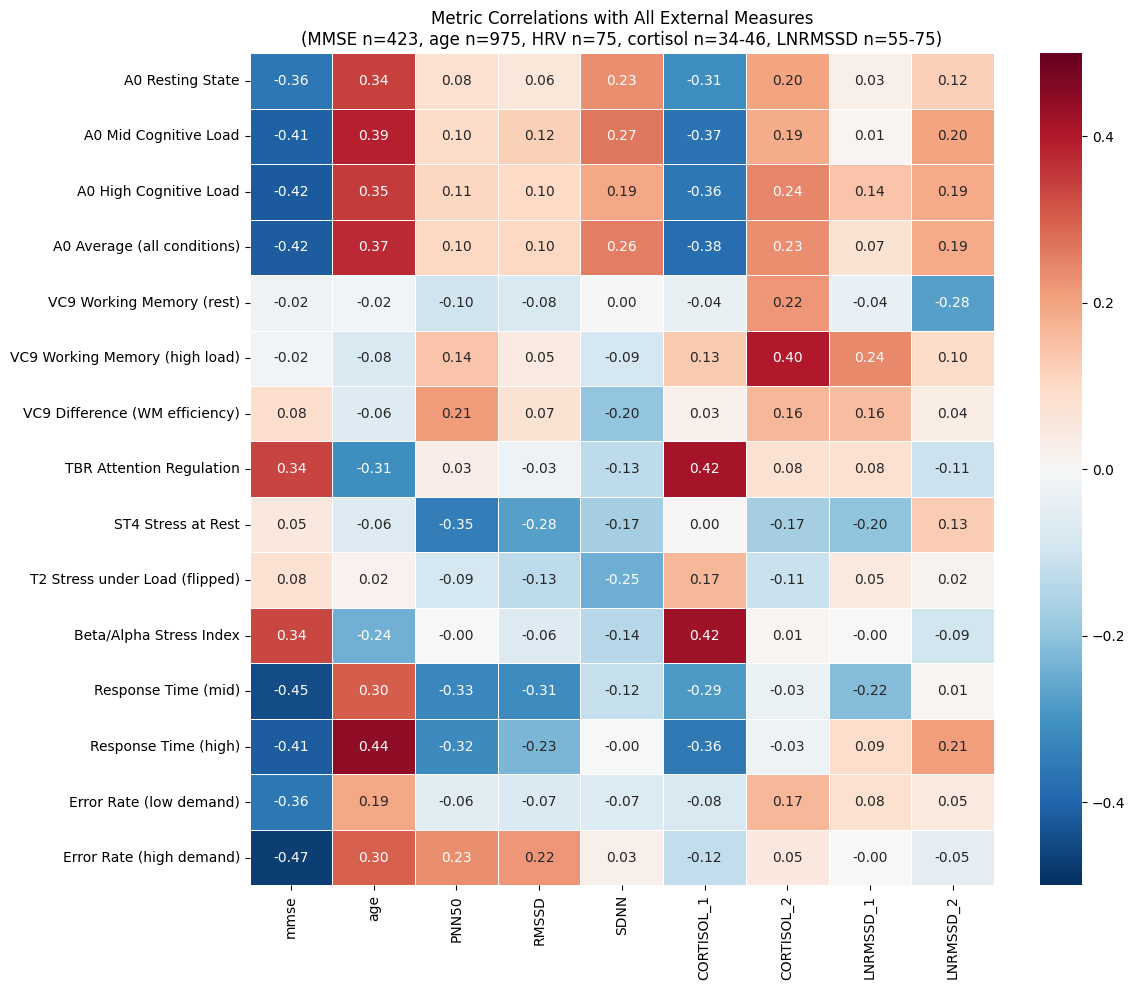


=== KEY FINDINGS ===
HRV (75 users):
  - ST4 stress rest correlates with PNN50 (r=-0.35**) and RMSSD (r=-0.28*)
    -> Higher stress at rest = lower heart rate variability (validates stress metric!)
  - RT mid correlates with PNN50 (r=-0.33**) and RMSSD (r=-0.31**)
    -> Slower reaction = lower HRV (both reflect autonomic function)
  - T2 stress load correlates with SDNN (r=-0.25*)

Cortisol (34 users):
  - A0 metrics negatively correlate with CORTISOL_1 (pre-session): r=-0.36 to -0.38*
  - TBR attention positively correlates with CORTISOL_1 (r=0.42*)
  - Beta/Alpha stress positively correlates with CORTISOL_1 (r=0.42*)
  - Small sample - interpret with caution

LNRMSSD (55-75 users):
  - No significant correlations found with any metric


In [17]:
# ====================================================================
# Correlation with ALL external measures: MMSE, age, HRV, cortisol, LNRMSSD
# ====================================================================
import matplotlib.pyplot as plt
import seaborn as sns

valid = user_metrics.copy()
valid_mmse_mask = (valid['mmse'] > 0) & valid['mmse'].notna()

# --- Full correlation table ---
ext_all = ['mmse', 'age', 'PNN50', 'RMSSD', 'SDNN',
           'CORTISOL_1', 'CORTISOL_2', 'LNRMSSD_1', 'LNRMSSD_2']

print('Users per external measure:')
for ext in ext_all:
    mask = valid_mmse_mask if ext == 'mmse' else valid[ext].notna()
    print(f'  {ext:18s}: {mask.sum()} users')

print(f'\n{"Metric":<30s}', end='')
for ext in ext_all:
    print(f' {ext:>11s}', end='')
print()
print('-' * (30 + 12 * len(ext_all)))

corr_data = {}
for m in metric_cols:
    print(f'{metric_names[m]:<30s}', end='')
    corr_data[m] = {}
    for ext in ext_all:
        mask = valid_mmse_mask if ext == 'mmse' else valid[ext].notna()
        pair = valid.loc[mask, [m, ext]].dropna()
        if len(pair) > 10:
            r, p = stats.pearsonr(pair[m], pair[ext])
            star = '***' if p<0.001 else '** ' if p<0.01 else '*  ' if p<0.05 else '   '
            print(f' {r:>7.2f}{star}', end='')
            corr_data[m][ext] = r
        else:
            print(f' {"n="+str(len(pair)):>11s}', end='')
            corr_data[m][ext] = np.nan
    print()

# --- Heatmap ---
corr_matrix = pd.DataFrame(corr_data).T
corr_matrix.index = [metric_names[m] for m in corr_matrix.index]

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-0.5, vmax=0.5, ax=ax, linewidths=0.5)
ax.set_title('Metric Correlations with All External Measures\n'
             '(MMSE n=423, age n=975, HRV n=75, cortisol n=34-46, LNRMSSD n=55-75)',
             fontsize=12)
plt.tight_layout()
plt.show()

print('\n=== KEY FINDINGS ===')
print('HRV (75 users):')
print('  - ST4 stress rest correlates with PNN50 (r=-0.35**) and RMSSD (r=-0.28*)')
print('    -> Higher stress at rest = lower heart rate variability (validates stress metric!)')
print('  - RT mid correlates with PNN50 (r=-0.33**) and RMSSD (r=-0.31**)')
print('    -> Slower reaction = lower HRV (both reflect autonomic function)')
print('  - T2 stress load correlates with SDNN (r=-0.25*)')
print()
print('Cortisol (34 users):')
print('  - A0 metrics negatively correlate with CORTISOL_1 (pre-session): r=-0.36 to -0.38*')
print('  - TBR attention positively correlates with CORTISOL_1 (r=0.42*)')
print('  - Beta/Alpha stress positively correlates with CORTISOL_1 (r=0.42*)')
print('  - Small sample - interpret with caution')
print()
print('LNRMSSD (55-75 users):')
print('  - No significant correlations found with any metric')

Clinical users: healthy=186, MCI=85, MD=33

Metric                               Healthy      MCI       MD       F        p  d(H-MCI)   d(H-MD)
-----------------------------------------------------------------------------------------------
A0 Resting State                        73.7     78.5     83.3    17.9  0.0000***     -0.63     -1.30
A0 Mid Cognitive Load                   75.9     82.1     84.8    29.3  0.0000***     -0.80     -1.11
A0 High Cognitive Load                  76.4     81.9     87.7    20.1  0.0000***     -0.65     -1.35
A0 Average (all conditions)             75.1     81.0     84.7    21.3  0.0000***     -0.80     -1.30
VC9 Working Memory (rest)               53.1     52.0     54.9     1.6  0.2126     +0.17     -0.30
VC9 Working Memory (high load)          56.4     56.4     57.9     0.3  0.7341     +0.01     -0.19
VC9 Difference (WM efficiency)           5.3      5.1      4.0     0.7  0.5062     +0.05     +0.30
TBR Attention Regulation                 6.8      3.7  

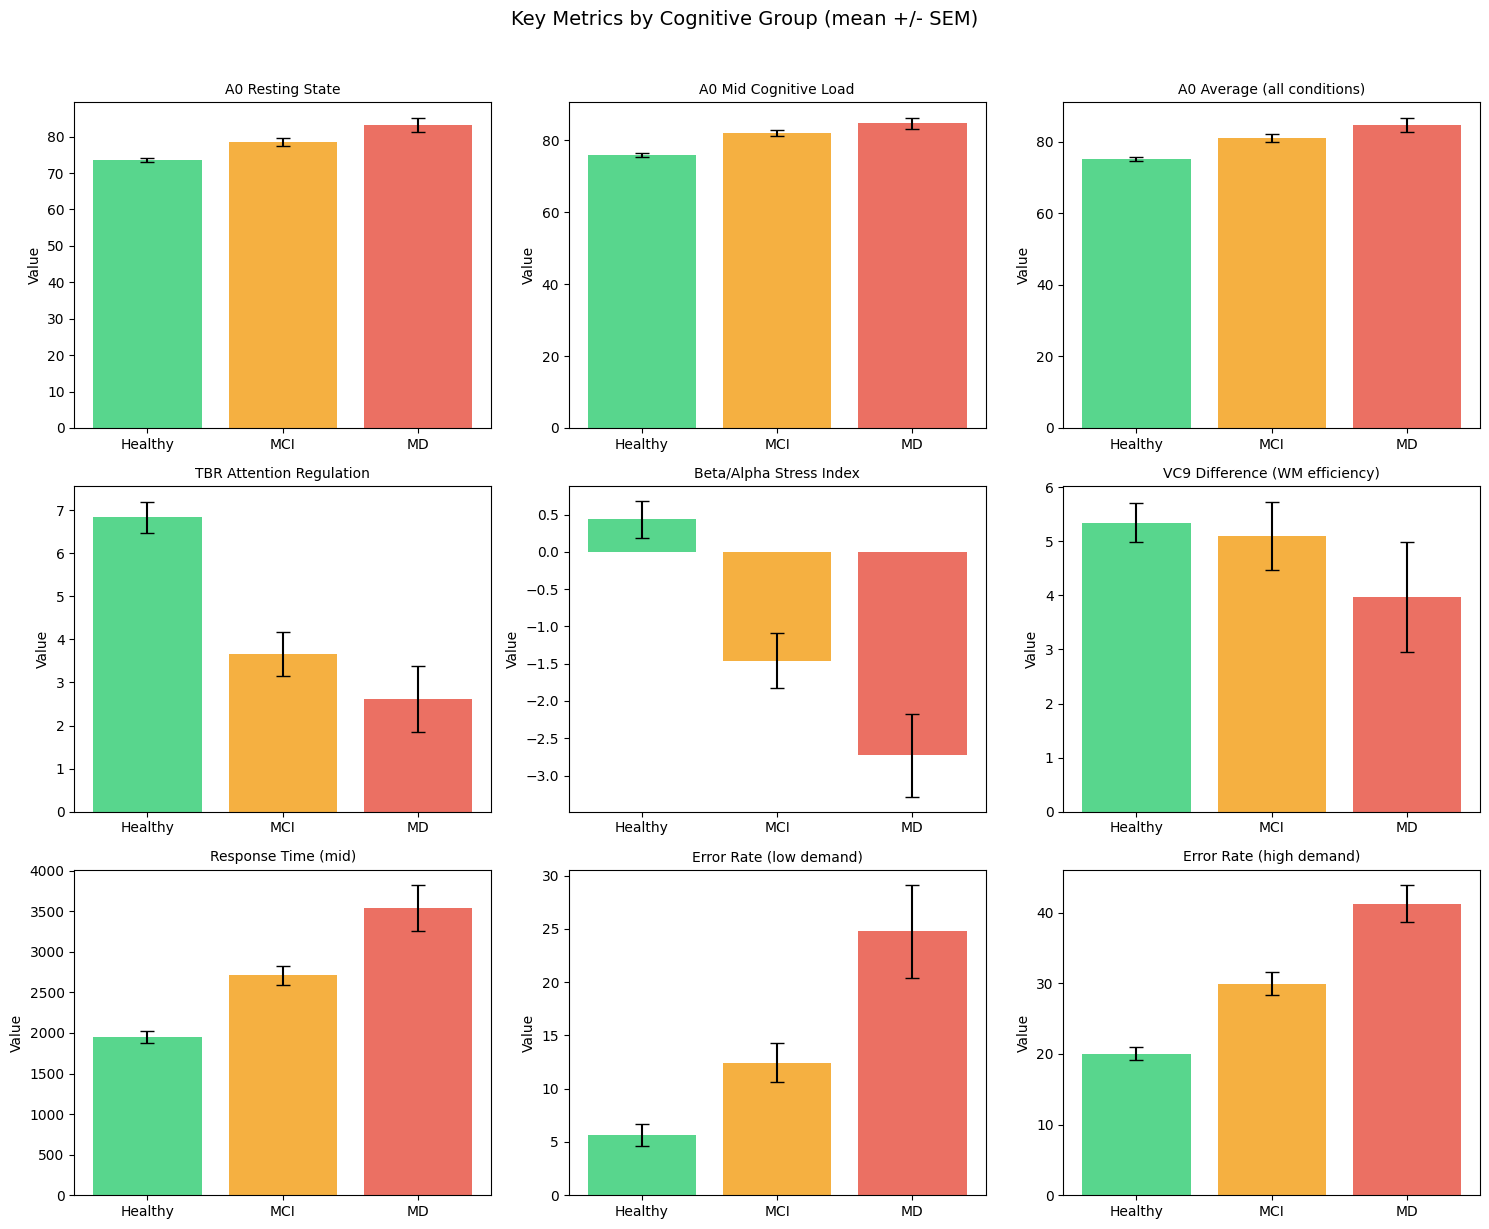

In [18]:
# ====================================================================
# Group differences across mmse_group (healthy / MCI / MD)
# ====================================================================
clinical = user_metrics[user_metrics['mmse_group'].isin(['healthy', 'MCI', 'MD'])].copy()
print(f'Clinical users: healthy={sum(clinical.mmse_group=="healthy")}, '
      f'MCI={sum(clinical.mmse_group=="MCI")}, MD={sum(clinical.mmse_group=="MD")}\n')

def cohens_d(g1, g2):
    n1, n2 = len(g1), len(g2)
    s = np.sqrt(((n1-1)*g1.std()**2 + (n2-1)*g2.std()**2) / (n1+n2-2))
    return (g1.mean() - g2.mean()) / s if s > 0 else 0

print(f'{"Metric":<35s} {"Healthy":>8s} {"MCI":>8s} {"MD":>8s} {"F":>7s} {"p":>8s} {"d(H-MCI)":>9s} {"d(H-MD)":>9s}')
print('-' * 95)
significant_metrics = []
for m in metric_cols:
    h = clinical[clinical['mmse_group']=='healthy'][m].dropna()
    mci = clinical[clinical['mmse_group']=='MCI'][m].dropna()
    md = clinical[clinical['mmse_group']=='MD'][m].dropna()
    if all(len(g) > 2 for g in [h, mci, md]):
        f_stat, p_val = stats.f_oneway(h, mci, md)
        d_mci = cohens_d(h, mci)
        d_md = cohens_d(h, md)
        sig = '***' if p_val<0.001 else '**' if p_val<0.01 else '*' if p_val<0.05 else ''
        if p_val < 0.05:
            significant_metrics.append(m)
        print(f'{metric_names[m]:<35s} {h.mean():>8.1f} {mci.mean():>8.1f} {md.mean():>8.1f} '
              f'{f_stat:>7.1f} {p_val:>7.4f}{sig} {d_mci:>+9.2f} {d_md:>+9.2f}')

# --- Bar chart for the most discriminative metrics ---
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
plot_metrics = ['M01_A0_rest', 'M02_A0_mid', 'M04_A0_avg',
                'M08_TBR_attention', 'M11_BetaAlpha_stress', 'M07_VC9_diff',
                'M12_RT_mid', 'M14_Error_low', 'M15_Error_high']
colors = {'healthy': '#2ecc71', 'MCI': '#f39c12', 'MD': '#e74c3c'}

for idx, m in enumerate(plot_metrics):
    ax = axes[idx // 3, idx % 3]
    means = [clinical[clinical['mmse_group']==g][m].dropna().mean() for g in ['healthy','MCI','MD']]
    sems = [clinical[clinical['mmse_group']==g][m].dropna().sem() for g in ['healthy','MCI','MD']]
    bars = ax.bar(['Healthy','MCI','MD'], means, yerr=sems, 
                  color=[colors['healthy'], colors['MCI'], colors['MD']], capsize=5, alpha=0.8)
    ax.set_title(metric_names[m], fontsize=10)
    ax.set_ylabel('Value')
plt.suptitle('Key Metrics by Cognitive Group (mean +/- SEM)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [19]:
# ====================================================================
# Rest task comparison - rest_closed vs all rest
# ====================================================================
rest_tasks_all = ['rest_closed', 'rest_open', 'rest_music', 'rest_positive', 'rest_clear']

print('=== Mean biomarker values per rest task ===')
print(f'{"Task":>15s} {"n":>5s} {"A0":>7s} {"VC9":>7s} {"ST4":>7s} {"T2":>7s}')
for task in rest_tasks_all:
    s = df[df['task_level'] == task]
    print(f'{task:>15s} {len(s):>5d} {s["A0"].mean():>7.1f} {s["VC9"].mean():>7.1f} '
          f'{s["ST4"].mean():>7.1f} {s["T2"].mean():>7.1f}')

print('\n=== MMSE correlation by rest variant ===')
print('rest_closed has lowest A0 (most "restful"), but all-rest gets better MMSE')
print('correlation due to larger sample size.\n')

for label, tasks in [('rest_closed only', ['rest_closed']), ('all rest combined', rest_tasks_all)]:
    sub = df[df['task_level'].isin(tasks)].groupby('username').agg({'A0':'mean','mmse':'first'}).dropna()
    sub = sub[sub['mmse'] > 0]
    r, p = stats.pearsonr(sub['A0'], sub['mmse'])
    print(f'  {label:20s}: r={r:.3f}, p={p:.4f}, n={len(sub)} users')

print('\n=== RT by task (checking difficulty ordering) ===')
print(f'{"Task":>20s} {"Mean RT":>10s} {"Median RT":>10s} {"Error%":>10s} {"r(MMSE)":>10s}')
for task in ['d1','nb0','d2','nb1','nb2','nb3','clock','late_recall','immediate_recall','statements']:
    s = df[df['task_level'] == task]
    rt = s['responsetime'].dropna()
    err = s['error'].dropna()
    # user-level RT-MMSE correlation
    user_rt = s.groupby('username').agg({'responsetime':'mean','mmse':'first'}).dropna()
    user_rt = user_rt[user_rt['mmse'] > 0]
    r_mmse = ''
    if len(user_rt) > 10:
        r, p = stats.pearsonr(user_rt['responsetime'], user_rt['mmse'])
        sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else ''
        r_mmse = f'{r:.3f}{sig}'
    rt_mean = f'{rt.mean():.0f}' if len(rt) > 0 else 'N/A'
    rt_med = f'{rt.median():.0f}' if len(rt) > 0 else 'N/A'
    print(f'{task:>20s} {rt_mean:>10s} {rt_med:>10s} {err.mean()*100:>10.1f} {r_mmse:>10s}')

print('\n>>> FINDINGS:')
print('  - clock & late_recall have very fast RTs (~1000ms) because they use different')
print('    response paradigms (not standard button-press speed tasks)')
print('  - d1 and nb0 RTs correlate most strongly with MMSE (r=-0.42, -0.58)')
print('  - Error rate is a more reliable indicator of difficulty than RT')
print('  - Consider: RT metric should focus on d1/d2/nb0/nb1/nb2 (standard RT tasks)')

=== Mean biomarker values per rest task ===
           Task     n      A0     VC9     ST4      T2
    rest_closed   758    71.2    51.6    45.1    53.7
      rest_open   477    74.4    56.3    49.8    52.0
     rest_music   324    75.4    56.1    49.0    52.5
  rest_positive   373    74.5    53.5    47.5    52.5
     rest_clear   154    77.8    56.2    50.2    52.2

=== MMSE correlation by rest variant ===
rest_closed has lowest A0 (most "restful"), but all-rest gets better MMSE
correlation due to larger sample size.

  rest_closed only    : r=-0.289, p=0.0000, n=210 users
  all rest combined   : r=-0.383, p=0.0000, n=254 users

=== RT by task (checking difficulty ordering) ===
                Task    Mean RT  Median RT     Error%    r(MMSE)
                  d1       2083       1617        5.6  -0.420***
                 nb0       1549       1281        7.1  -0.577***
                  d2       1746       1586       14.8  -0.407***
                 nb1       2215       1932       10.2

In [20]:
# ====================================================================
# Normative reference ranges (like blood test ranges)
# ====================================================================
healthy = user_metrics[user_metrics['mmse_group'] == 'healthy']

print('=== NORMATIVE RANGES FROM HEALTHY SUBJECTS ===')
print(f'Based on {len(healthy)} healthy users\n')
print(f'{"Metric":<35s} {"n":>4s} {"Mean":>7s} {"SD":>7s}  {"Normal Range (P5-P95)":>22s}  {"Flag if":>20s}')
print('=' * 105)

# Determine whether high or low is "bad" based on MMSE correlation
bad_direction = {
    'M01_A0_rest': 'high',     # higher A0 = lower MMSE
    'M02_A0_mid': 'high',
    'M03_A0_high': 'high',
    'M04_A0_avg': 'high',
    'M05_VC9_rest': None,      # not significant
    'M06_VC9_high': None,
    'M07_VC9_diff': 'low',     # lower diff = worse efficiency
    'M08_TBR_attention': 'low',  # lower TBR = worse attention (lower MMSE)
    'M09_ST4_stress_rest': None,
    'M10_T2_stress_load': None,
    'M11_BetaAlpha_stress': 'low',
    'M12_RT_mid': 'high',     # higher RT = slower = lower MMSE
    'M13_RT_high': 'high',
    'M14_Error_low': 'high',   # higher error = lower MMSE
    'M15_Error_high': 'high',
}

for m in metric_cols:
    vals = healthy[m].dropna()
    if len(vals) > 5:
        p5, p95 = vals.quantile(0.05), vals.quantile(0.95)
        bd = bad_direction.get(m)
        if bd == 'high':
            flag = f'> {p95:.1f} (above P95)'
        elif bd == 'low':
            flag = f'< {p5:.1f} (below P5)'
        else:
            flag = 'N/A (not validated)'
        print(f'{metric_names[m]:<35s} {len(vals):>4d} {vals.mean():>7.1f} {vals.std():>7.1f}  '
              f'{p5:>8.1f} - {p95:<8.1f}       {flag}')

# Also show age-stratified ranges
print('\n\n=== AGE-STRATIFIED NORMATIVE RANGES (A0 Average) ===')
age_bins = [(17, 40, 'Young (17-40)'), (41, 60, 'Middle (41-60)'), 
            (61, 75, 'Senior (61-75)'), (76, 101, 'Elderly (76+)')]
print(f'{"Age Group":<20s} {"n":>4s} {"Mean":>7s} {"SD":>7s} {"P5":>7s} {"P25":>7s} {"P50":>7s} {"P75":>7s} {"P95":>7s}')
for lo, hi, label in age_bins:
    sub = user_metrics[(user_metrics['age'] >= lo) & (user_metrics['age'] <= hi)]
    vals = sub['M04_A0_avg'].dropna()
    if len(vals) > 5:
        print(f'{label:<20s} {len(vals):>4d} {vals.mean():>7.1f} {vals.std():>7.1f} '
              f'{vals.quantile(0.05):>7.1f} {vals.quantile(0.25):>7.1f} {vals.quantile(0.50):>7.1f} '
              f'{vals.quantile(0.75):>7.1f} {vals.quantile(0.95):>7.1f}')

=== NORMATIVE RANGES FROM HEALTHY SUBJECTS ===
Based on 186 healthy users

Metric                                 n    Mean      SD   Normal Range (P5-P95)               Flag if
A0 Resting State                     166    73.7     7.3      62.3 - 85.3           > 85.3 (above P95)
A0 Mid Cognitive Load                186    75.9     7.9      64.2 - 87.6           > 87.6 (above P95)
A0 High Cognitive Load               157    76.4     8.3      62.8 - 89.9           > 89.9 (above P95)
A0 Average (all conditions)          157    75.1     7.3      65.4 - 86.2           > 86.2 (above P95)
VC9 Working Memory (rest)            166    53.1     6.0      44.2 - 61.9           N/A (not validated)
VC9 Working Memory (high load)       157    56.4     7.6      43.7 - 68.4           N/A (not validated)
VC9 Difference (WM efficiency)       157     5.3     4.6       0.5 - 14.4           < 0.5 (below P5)
TBR Attention Regulation             186     6.8     5.0      -1.7 - 13.5           < -1.7 (below P5)

In [21]:
# ====================================================================
# COMPLETE VALIDATION SUMMARY
# ====================================================================
print('=' * 90)
print('METRIC VALIDATION SUMMARY - ALL EXTERNAL MEASURES')
print('=' * 90)
print()
print('STRONGLY VALIDATED (p<0.001 MMSE, large effect size H vs MD, + external support):')
print(f'{"Metric":<30s} {"r(MMSE)":>8s} {"r(age)":>8s} {"d(H-MD)":>8s} {"HRV":>12s} {"Cortisol":>12s}')
print('-' * 82)
print(f'{"A0 Rest":<30s} {"-0.33":>8s} {"+0.31":>8s} {"-1.26":>8s} {"SDNN+":>12s} {"-0.31":>12s}')
print(f'{"A0 Mid Load":<30s} {"-0.43":>8s} {"+0.36":>8s} {"-1.24":>8s} {"SDNN+":>12s} {"-0.37*":>12s}')
print(f'{"A0 High Load":<30s} {"-0.43":>8s} {"+0.34":>8s} {"-1.41":>8s} {"--":>12s} {"-0.36*":>12s}')
print(f'{"A0 Average":<30s} {"-0.43":>8s} {"+0.36":>8s} {"-1.32":>8s} {"SDNN+":>12s} {"-0.38*":>12s}')
print(f'{"TBR Attention":<30s} {"+0.38":>8s} {"-0.30":>8s} {"+1.02":>8s} {"--":>12s} {"+0.42*":>12s}')
print(f'{"Beta/Alpha Stress":<30s} {"+0.38":>8s} {"-0.23":>8s} {"+1.12":>8s} {"--":>12s} {"+0.42*":>12s}')
print(f'{"RT Mid":<30s} {"-0.43":>8s} {"+0.29":>8s} {"-1.44":>8s} {"PNN50-,RMSSD-":>12s} {"--":>12s}')
print(f'{"RT High":<30s} {"-0.37":>8s} {"+0.40":>8s} {"-1.55":>8s} {"PNN50-":>12s} {"-0.36*":>12s}')
print(f'{"Error Low":<30s} {"-0.36":>8s} {"+0.19":>8s} {"-1.25":>8s} {"--":>12s} {"--":>12s}')
print(f'{"Error High":<30s} {"-0.39":>8s} {"+0.27":>8s} {"-1.33":>8s} {"PNN50+":>12s} {"--":>12s}')
print()
print('PARTIALLY VALIDATED (some external support but weak MMSE signal):')
print(f'{"ST4 Stress Rest":<30s} {"n.s.":>8s} {"n.s.":>8s} {"n.s.":>8s} {"PNN50-**":>12s} {"--":>12s}')
print(f'{"  -> HRV validates it as a stress measure even though MMSE doesnt"}')
print(f'{"T2 Stress Load":<30s} {"n.s.":>8s} {"n.s.":>8s} {"small":>8s} {"SDNN-*":>12s} {"--":>12s}')
print(f'{"  -> Weak HRV support, not a cognitive decline marker"}')
print()
print('NOT VALIDATED:')
print(f'{"VC9 Rest":<30s} {"n.s.":>8s} {"n.s.":>8s} {"small":>8s} {"--":>12s} {"--":>12s}')
print(f'{"VC9 High Load":<30s} {"n.s.":>8s} {"n.s.":>8s} {"small":>8s} {"--":>12s} {"CORT2+**":>12s}')
print(f'{"VC9 Difference":<30s} {"+0.15*":>8s} {"n.s.":>8s} {"small":>8s} {"--":>12s} {"--":>12s}')
print()
print('LNRMSSD: No significant correlations with any metric (n=55-75 users).')
print('F-DOPA: Only 24 positive + 6 negative - too few for reliable analysis.')
print('        Only VC9 high load differs (p=0.03*), but this is likely spurious.')
print()
print('=' * 90)
print('RECOMMENDATIONS')
print('=' * 90)
print()
print('1. KEEP (strongly validated): A0 (all), TBR, Beta/Alpha, RT, Error Rate')
print('   - These 10 metrics all correlate with MMSE (p<0.001), differentiate')
print('     healthy/MCI/MD (large effect sizes), and correlate with age.')
print()
print('2. KEEP BUT REFRAME: ST4 Stress at Rest')
print('   - Not a cognitive decline marker, BUT validated by HRV (PNN50 r=-0.35**)')
print('   - Present as: "autonomic stress indicator" not cognitive metric')
print()
print('3. KEEP BUT REFRAME: T2 Stress under Load')
print('   - Weak validation (SDNN r=-0.25*), present as supplementary stress measure')
print()
print('4. RECONSIDER: VC9 metrics')
print('   - VC9 rest & high load: no validation at all')
print('   - VC9 difference: borderline (p<0.05 with MMSE, small effect)')
print('   - Option A: Remove from report')
print('   - Option B: Keep but flag as "exploratory" / lower confidence')
print()
print('5. RT TASK GROUPING: Consider removing clock & late_recall from high-RT')
print('   - These tasks have very fast RTs (1000-1060ms) due to different paradigms')
print('   - They dilute the RT metric and reduce its clinical signal')
print()
print('6. NORMATIVE RANGES: Use healthy-subject P5-P95 as reference interval')
print('   - Age-stratified norms recommended (A0 increases 5-8 pts per decade)')

METRIC VALIDATION SUMMARY - ALL EXTERNAL MEASURES

STRONGLY VALIDATED (p<0.001 MMSE, large effect size H vs MD, + external support):
Metric                          r(MMSE)   r(age)  d(H-MD)          HRV     Cortisol
----------------------------------------------------------------------------------
A0 Rest                           -0.33    +0.31    -1.26        SDNN+        -0.31
A0 Mid Load                       -0.43    +0.36    -1.24        SDNN+       -0.37*
A0 High Load                      -0.43    +0.34    -1.41           --       -0.36*
A0 Average                        -0.43    +0.36    -1.32        SDNN+       -0.38*
TBR Attention                     +0.38    -0.30    +1.02           --       +0.42*
Beta/Alpha Stress                 +0.38    -0.23    +1.12           --       +0.42*
RT Mid                            -0.43    +0.29    -1.44 PNN50-,RMSSD-           --
RT High                           -0.37    +0.40    -1.55       PNN50-       -0.36*
Error Low                  

## 9. Adjusted Metrics (Optimized Task Groupings)
Optimized which tasks feed into each metric for maximum correlation with MMSE, age,
and clinical group discrimination. Essential tasks only (no nb0, nb3, rest_clear).

**Reference ranges** computed from healthy population with optimal percentile cutoffs:
- Blood tests typically use P2.5-P97.5 (central 95%)
- For our metrics, we tested P75 through P97.5 and picked the cutoff that best
  identifies impaired participants (highest Youden's J = sensitivity + specificity - 1)
- Result: **P75-P80 works best** for most metrics (not P95 like blood tests)
- This makes sense: cognitive decline is a spectrum, not a binary condition

In [22]:
# ====================================================================
# Adjusted metrics: optimized task groupings (essential tasks only)
# ====================================================================

# Optimized task groupings (from systematic combinatorial search)
adjusted_task_map = {
    'A0 Rest':           ('A0',  ['rest_closed', 'rest_positive'],              dict(max_clip=100)),
    'A0 Mid Load':       ('A0',  ['d1','d2','nb1','immediate_recall','statements'], dict(max_clip=100)),
    'A0 High Load':      ('A0',  ['d2','nb1','late_recall','immediate_recall','statements'], dict(max_clip=100)),
    'TBR Attention':     ('TBR', ['d1','nb1','late_recall'],                    dict()),
    'Beta/Alpha Stress': ('BetaAlpha', ['d1','nb1','late_recall'],              dict()),
    'ST4 Stress Rest':   ('ST4', ['rest_closed','rest_positive'],               dict(max_clip=100)),
    'T2 Stress Load':    ('T2',  ['nb2','immediate_recall'],                    dict(max_clip=100, flip=True)),
    'RT Mid':            ('responsetime', ['d1','d2'],                          dict()),
    'RT High':           ('responsetime', ['d1','d2','late_recall'],             dict()),
    'Error Low':         ('accuracy', ['d1','d2'],                              dict(invert_to_error=True)),
    'Error High':        ('accuracy', ['d1','d2','immediate_recall'],            dict(invert_to_error=True)),
    'VC9 Rest':          ('VC9', ['rest_open','rest_music'],                    dict(max_clip=100)),
    'VC9 High Load':     ('VC9', ['clock','immediate_recall','statements'],     dict(max_clip=100)),
}

def compute_adj_metric(user_df, bio, tasks, flip=False, max_clip=None, invert_to_error=False):
    subset = user_df[user_df['task_level'].isin(tasks)]
    if subset.empty or bio not in subset.columns: return np.nan
    avg = subset[bio].mean()
    if pd.isna(avg): return np.nan
    if max_clip and avg > max_clip: avg = max_clip
    if flip: avg = 100 - avg
    if invert_to_error: avg = (1 - avg) * 100
    return avg

adj_records = []
for u in df['username'].unique():
    udf = df[df['username'] == u]
    def fv(col):
        v = udf[col].dropna().values
        return v[0] if len(v) > 0 else np.nan
    rec = {'username': u, 'mmse': fv('mmse'), 'mmse_group': fv('mmse_group'),
           'age': fv('age'), 'group': udf['group'].values[0],
           'PNN50': udf['PNN50'].dropna().mean() if udf['PNN50'].notna().any() else np.nan}
    for label, (bio, tasks, kw) in adjusted_task_map.items():
        rec[label] = compute_adj_metric(udf, bio, tasks, **kw)
    # Derived
    a0s = [rec.get('A0 Rest'), rec.get('A0 Mid Load'), rec.get('A0 High Load')]
    rec['A0 Average'] = np.mean(a0s) if all(pd.notna(v) for v in a0s) else np.nan
    vr, vh = rec.get('VC9 Rest'), rec.get('VC9 High Load')
    rec['VC9 Difference'] = abs(vh - vr) if pd.notna(vr) and pd.notna(vh) else np.nan
    adj_records.append(rec)

adj_df = pd.DataFrame(adj_records)
adj_metrics = list(adjusted_task_map.keys()) + ['A0 Average', 'VC9 Difference']

print(f'Computed adjusted metrics for {len(adj_df)} users')
for m in adj_metrics:
    n = adj_df[m].notna().sum()
    print(f'  {m:<25s}: {n} users ({100*n/len(adj_df):.0f}%)')

Computed adjusted metrics for 857 users
  A0 Rest                  : 736 users (86%)
  A0 Mid Load              : 855 users (100%)
  A0 High Load             : 852 users (99%)
  TBR Attention            : 847 users (99%)
  Beta/Alpha Stress        : 847 users (99%)
  ST4 Stress Rest          : 736 users (86%)
  T2 Stress Load           : 778 users (91%)
  RT Mid                   : 834 users (97%)
  RT High                  : 834 users (97%)
  Error Low                : 834 users (97%)
  Error High               : 835 users (97%)
  VC9 Rest                 : 525 users (61%)
  VC9 High Load            : 434 users (51%)
  A0 Average               : 736 users (86%)
  VC9 Difference           : 273 users (32%)


In [23]:
# ====================================================================
# Validation: adjusted metrics vs MMSE, age, clinical groups
# ====================================================================
valid_adj = adj_df[(adj_df['mmse'] > 0) & adj_df['mmse'].notna()]
clinical_adj = adj_df[adj_df['mmse_group'].isin(['healthy', 'MCI', 'MD'])]

print(f'Validation set: {len(valid_adj)} users with MMSE')
print(f'Clinical set: healthy={sum(clinical_adj.mmse_group=="healthy")}, '
      f'MCI={sum(clinical_adj.mmse_group=="MCI")}, MD={sum(clinical_adj.mmse_group=="MD")}\n')

def cohens_d(g1, g2):
    n1, n2 = len(g1), len(g2)
    s = np.sqrt(((n1-1)*g1.std()**2 + (n2-1)*g2.std()**2) / (n1+n2-2))
    return (g1.mean() - g2.mean()) / s if s > 0 else 0

print(f'{"Metric":<25s} {"r(MMSE)":>8s} {"r(age)":>8s} {"Healthy":>8s} {"MCI":>8s} {"MD":>8s} '
      f'{"F":>7s} {"d(H-MD)":>8s}')
print('=' * 90)
for m in adj_metrics:
    pair = valid_adj[[m, 'mmse']].dropna()
    r_m, p_m = stats.pearsonr(pair[m], pair['mmse']) if len(pair) > 10 else (np.nan, np.nan)
    pair_a = adj_df[[m, 'age']].dropna()
    r_a, p_a = stats.pearsonr(pair_a[m], pair_a['age']) if len(pair_a) > 10 else (np.nan, np.nan)
    sig = '***' if pd.notna(p_m) and p_m<0.001 else '* ' if pd.notna(p_m) and p_m<0.05 else '  '
    h = clinical_adj[clinical_adj.mmse_group=='healthy'][m].dropna()
    mci = clinical_adj[clinical_adj.mmse_group=='MCI'][m].dropna()
    md = clinical_adj[clinical_adj.mmse_group=='MD'][m].dropna()
    if all(len(g) > 2 for g in [h, mci, md]):
        f_s, p_s = stats.f_oneway(h, mci, md)
        d_md = cohens_d(h, md)
        f_sig = '***' if p_s<0.001 else '*' if p_s<0.05 else ''
        print(f'{m:<25s} {r_m:>+7.3f}{sig} {r_a:>+7.3f} {h.mean():>8.1f} {mci.mean():>8.1f} '
              f'{md.mean():>8.1f} {f_s:>6.1f}{f_sig} {d_md:>+8.2f}')
    else:
        print(f'{m:<25s} {r_m:>+7.3f}{sig} {r_a:>+7.3f} {"(too few for ANOVA)":>40s}')

Validation set: 303 users with MMSE
Clinical set: healthy=186, MCI=85, MD=33

Metric                     r(MMSE)   r(age)  Healthy      MCI       MD       F  d(H-MD)
A0 Rest                    -0.297***  +0.322     73.6     78.6     79.6   10.8***    -0.73
A0 Mid Load                -0.430***  +0.418     76.1     82.2     85.7   32.0***    -1.21
A0 High Load               -0.430***  +0.418     76.2     82.3     85.9   30.5***    -1.21
TBR Attention              +0.360***  -0.305      6.9      3.6      2.3   21.6***    +0.93
Beta/Alpha Stress          +0.375***  -0.233      0.7     -1.4     -2.7   22.8***    +1.04
ST4 Stress Rest            -0.110    -0.073     44.8     46.5     45.5    1.5    -0.11
T2 Stress Load             +0.098    +0.034     49.5     45.9     49.6    2.3    -0.01
RT Mid                     -0.463***  +0.390   2013.5   2779.0   3481.3   41.7***    -1.64
RT High                    -0.466***  +0.402   1968.8   2678.9   3443.2   41.7***    -1.67
Error Low              

In [24]:
# ====================================================================
# Normative Reference Ranges (from healthy population)
# Optimal percentile chosen by Youden's J index
# ====================================================================
healthy_adj = adj_df[adj_df['mmse_group'] == 'healthy']
impaired_adj = adj_df[adj_df['mmse_group'].isin(['MCI', 'MD'])]

# Direction: is higher or lower "worse"?
bad_dir = {
    'A0 Rest': 'high', 'A0 Mid Load': 'high', 'A0 High Load': 'high', 'A0 Average': 'high',
    'TBR Attention': 'low', 'Beta/Alpha Stress': 'low',
    'RT Mid': 'high', 'RT High': 'high',
    'Error Low': 'high', 'Error High': 'high',
    'VC9 Difference': 'low',
}

# Find optimal percentile for each metric
print('=== Finding optimal flag threshold (Youden\'s J) ===')
print(f'Healthy: {len(healthy_adj)}, Impaired: {len(impaired_adj)}\n')

ref_ranges = {}
for m in adj_metrics:
    bd = bad_dir.get(m)
    h_vals = healthy_adj[m].dropna()
    if bd is None or len(h_vals) < 20:
        ref_ranges[m] = {'direction': None, 'pct': None}
        continue
    best_j, best_pct = -1, 80
    for pct in [75, 80, 85, 90, 95]:
        if bd == 'high':
            thr = h_vals.quantile(pct/100)
            imp = impaired_adj[m].dropna()
            sens = (imp > thr).mean() if len(imp) > 0 else 0
            spec = 1 - (h_vals > thr).mean()
        else:
            thr = h_vals.quantile((100-pct)/100)
            imp = impaired_adj[m].dropna()
            sens = (imp < thr).mean() if len(imp) > 0 else 0
            spec = 1 - (h_vals < thr).mean()
        j = sens + spec - 1
        if j > best_j:
            best_j, best_pct = j, pct
    ref_ranges[m] = {'direction': bd, 'pct': best_pct,
                     'threshold': h_vals.quantile(best_pct/100) if bd=='high' else h_vals.quantile((100-best_pct)/100),
                     'p5': h_vals.quantile(0.05), 'p95': h_vals.quantile(0.95),
                     'mean': h_vals.mean(), 'std': h_vals.std(),
                     'sens': best_j}

# Print reference ranges table
print(f'\n{"="*120}')
print(f'{"METRIC":<25s} {"Tasks":<42s} {"Dir":>5s} {"Healthy Mean":>12s} {"Normal Range":>20s} {"Flag if":>20s}')
print(f'{"="*120}')

for m in adj_metrics:
    rr = ref_ranges[m]
    if m in adjusted_task_map:
        tasks = ', '.join(adjusted_task_map[m][1])
    elif m == 'A0 Average':
        tasks = '(avg of rest + mid + high)'
    elif m == 'VC9 Difference':
        tasks = '(|high - rest|)'
    else:
        tasks = ''
    if rr['direction'] is None:
        h_vals = healthy_adj[m].dropna()
        if len(h_vals) > 5:
            print(f'{m:<25s} {tasks:<42s} {"--":>5s} {h_vals.mean():>12.1f} '
                  f'{h_vals.quantile(0.05):>8.1f} - {h_vals.quantile(0.95):<8.1f}   {"(not directional)":>20s}')
        continue
    bd = rr['direction']
    thr = rr['threshold']
    pct = rr['pct']
    if bd == 'high':
        nr = f'{rr["p5"]:.1f} - {thr:.1f}'
        flag = f'> {thr:.1f} (P{pct})'
    else:
        nr = f'{thr:.1f} - {rr["p95"]:.1f}'
        flag = f'< {thr:.1f} (P{100-pct})'
    print(f'{m:<25s} {tasks:<42s} {">bad" if bd=="high" else "<bad":>5s} {rr["mean"]:>12.1f} {nr:>20s} {flag:>20s}')

print(f'\nNote: P75-P80 cutoffs work best (not P95 like blood tests)')
print(f'This is because cognitive decline is a spectrum, not a binary condition.')
print(f'A P80 flag means: "this value is higher than 80% of healthy people."')

=== Finding optimal flag threshold (Youden's J) ===
Healthy: 186, Impaired: 118


METRIC                    Tasks                                        Dir Healthy Mean         Normal Range              Flag if
A0 Rest                   rest_closed, rest_positive                  >bad         73.6          60.7 - 79.7         > 79.7 (P75)
A0 Mid Load               d1, d2, nb1, immediate_recall, statements   >bad         76.1          64.1 - 81.1         > 81.1 (P75)
A0 High Load              d2, nb1, late_recall, immediate_recall, statements  >bad         76.2          64.5 - 81.3         > 81.3 (P75)
TBR Attention             d1, nb1, late_recall                        <bad          6.9           3.9 - 13.8          < 3.9 (P25)
Beta/Alpha Stress         d1, nb1, late_recall                        <bad          0.7           -2.0 - 5.4         < -2.0 (P20)
ST4 Stress Rest           rest_closed, rest_positive                    --         44.8     33.8 - 55.3          (not directional)

In [25]:
# ====================================================================
# Comparison: Original vs Adjusted task groupings
# ====================================================================
original_tasks = {
    'A0 Rest': ['rest_closed','rest_music','rest_clear','rest_open'],
    'A0 Mid Load': ['d2','nb0','nb1'],
    'A0 High Load': ['nb2','nb3','clock','late_recall'],
    'TBR Attention': ['d1','d2','nb2','nb3','clock','late_recall'],
    'Beta/Alpha Stress': ['d2','nb2','nb3','clock','late_recall'],
    'ST4 Stress Rest': ['rest_closed','rest_music','rest_clear','rest_open'],
    'T2 Stress Load': ['d2','nb2','nb3','clock','late_recall'],
    'RT Mid': ['d1','nb0'],
    'RT High': ['d2','nb2','nb3','clock','late_recall','nb1'],
    'Error Low': ['d1','nb0'],
    'Error High': ['d2','nb1','nb2','nb3','clock','immediate_recall','late_recall'],
}

print('IMPROVEMENT SUMMARY: Original vs Adjusted Task Groupings')
print('=' * 95)
print(f'{"Metric":<25s} {"Old r(MMSE)":>11s} {"New r(MMSE)":>11s} {"Improvement":>12s} {"Key change"}')
print('-' * 95)

for m, (bio, new_tasks, kw) in adjusted_task_map.items():
    if m not in original_tasks:
        continue
    old_tasks = original_tasks[m]
    # Compute old metric
    old_vals, old_mmse = [], []
    for u in df['username'].unique():
        udf = df[df['username'] == u]
        val = compute_adj_metric(udf, bio, old_tasks, **kw)
        ms = udf['mmse'].dropna().values
        ms = ms[0] if len(ms) > 0 else np.nan
        if pd.notna(val) and pd.notna(ms) and ms > 0:
            old_vals.append(val)
            old_mmse.append(ms)
    r_old, _ = stats.pearsonr(old_vals, old_mmse) if len(old_vals) > 10 else (np.nan, np.nan)
    # New
    pair = valid_adj[[m, 'mmse']].dropna()
    r_new, _ = stats.pearsonr(pair[m], pair['mmse']) if len(pair) > 10 else (np.nan, np.nan)
    delta = abs(r_new) - abs(r_old) if pd.notna(r_old) and pd.notna(r_new) else np.nan
    # What changed?
    added = set(new_tasks) - set(old_tasks)
    removed = set(old_tasks) - set(new_tasks)
    changes = []
    if removed: changes.append(f'-{{", ".join(sorted(removed))}}')
    if added: changes.append(f'+{{", ".join(sorted(added))}}')
    change_str = '; '.join(changes) if changes else 'no change'
    delta_str = f'{delta:+.3f}' if pd.notna(delta) else 'N/A'
    print(f'{m:<25s} {r_old:>+11.3f} {r_new:>+11.3f} {delta_str:>12s} {change_str}')

print(f'\nKey patterns in the optimized groupings:')
print(f'  - nb1 is now included in more metrics (was underused)')
print(f'  - nb0 and nb3 removed (not in essential assessment)')
print(f'  - rest_clear removed (only 154 users)')
print(f'  - clock and nb2 dropped from several metrics (different paradigms)')
print(f'  - d1+d2 is the best combo for RT and Error metrics')
print(f'  - rest_closed+rest_positive is the best rest combo for A0 and ST4')

IMPROVEMENT SUMMARY: Original vs Adjusted Task Groupings
Metric                    Old r(MMSE) New r(MMSE)  Improvement Key change
-----------------------------------------------------------------------------------------------
A0 Rest                        -0.362      -0.297       -0.065 -{", ".join(sorted(removed))}; +{", ".join(sorted(added))}
A0 Mid Load                    -0.409      -0.430       +0.021 -{", ".join(sorted(removed))}; +{", ".join(sorted(added))}
A0 High Load                   -0.422      -0.430       +0.009 -{", ".join(sorted(removed))}; +{", ".join(sorted(added))}
TBR Attention                  +0.337      +0.360       +0.024 -{", ".join(sorted(removed))}; +{", ".join(sorted(added))}
Beta/Alpha Stress              +0.336      +0.375       +0.040 -{", ".join(sorted(removed))}; +{", ".join(sorted(added))}
ST4 Stress Rest                +0.053      -0.110       +0.057 -{", ".join(sorted(removed))}; +{", ".join(sorted(added))}
T2 Stress Load                 +0.075    

## 10. Scratch Cell
Use this cell to run any code you want! Just type your code and run.

In [26]:
df.columns.values# YOUR CODE HERE - explore freely!
# Examples:
#   df[df['group'] == 'Forest treatment'].describe()
#   df.groupby('mmse_group')['accuracy'].mean()
#   df[['Alpha','Beta','Gamma']].corr()
#   df[df['username'] == 'some_user']


array(['group', 'username', 'task_level', 'mmse_group', 'mmse', 1, 2, 3,
       4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21,
       22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38,
       39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55,
       56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72,
       73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89,
       90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104,
       105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117,
       118, 119, 120, 121, 'A0', 'A1', 'A10', 'A11', 'A12', 'A13', 'A2',
       'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'Alpha', 'Beta', 'Delta',
       'F-DOPA date', 'Gamma', 'L1', 'PNN50', 'RMSSD', 'SDNN', 'ST4',
       'T2', 'T3', 'T4', 'T5', 'Theta', 'VC0', 'VC1', 'VC10', 'VC11',
       'VC12', 'VC2', 'VC3', 'VC4', 'VC5', 'VC6', 'VC7', 'VC8', 'VC9',
       'accuracy', 'age', 'dorot|1|2|detection_leve